# **03_baseline.ipynb**

## 1. **Import Libraries**

In [1]:
from pathlib import Path
import json
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU Available: True


## 2. **Data Loading and Preprocessing**

In [2]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Define the path to your dataset
data_dir = Path('/content/drive/MyDrive/Brain-Tumor-Mri-Deep-Learning/data/processed')

# Check the contents of the processed directory
print(f"Contents of {data_dir}:")
for item in os.listdir(data_dir):
    print(item)

Contents of /content/drive/MyDrive/Brain-Tumor-Mri-Deep-Learning/data/processed:
train
val
test


In [4]:
PROJECT_ROOT = Path(".")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

TRAIN_DIR = PROCESSED_DATA_DIR / "train"
VAL_DIR = PROCESSED_DATA_DIR / "val"
TEST_DIR = PROCESSED_DATA_DIR / "test"

MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
LOG_DIR = PROJECT_ROOT / "logs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
IMG_HEIGHT = IMG_SIZE[0]
IMG_WIDTH = IMG_SIZE[1]
CHANNELS = 3

BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Project root        : {PROJECT_ROOT.resolve()}")
print(f"Processed data path : {PROCESSED_DATA_DIR}")
print(f"Train path          : {TRAIN_DIR}")
print(f"Validation path     : {VAL_DIR}")
print(f"Test path           : {TEST_DIR}")

Project root        : /content
Processed data path : data/processed
Train path          : data/processed/train
Validation path     : data/processed/val
Test path           : data/processed/test


In [5]:
PROCESSED_DATA_DIR = Path('/content/drive/MyDrive/Brain-Tumor-Mri-Deep-Learning/data/processed')
TRAIN_DIR = PROCESSED_DATA_DIR / "train"
VAL_DIR = PROCESSED_DATA_DIR / "val"
TEST_DIR = PROCESSED_DATA_DIR / "test"

required_dirs = {
    "train": TRAIN_DIR,
    "validation": VAL_DIR,
    "test": TEST_DIR
}

for split_name, dir_path in required_dirs.items():
    if not dir_path.exists():
        raise FileNotFoundError(f"Không tìm thấy folder {split_name}: {dir_path}")

print("Tất cả folder train/val/test đã tồn tại.")

Tất cả folder train/val/test đã tồn tại.


In [6]:
def count_images_by_class(directory):
    image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    records = []

    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            image_count = 0

            for ext in image_extensions:
                image_count += len(list(class_dir.glob(ext)))

            records.append({
                "class_name": class_dir.name,
                "image_count": image_count
            })

    return pd.DataFrame(records)


train_count_df = count_images_by_class(TRAIN_DIR)
val_count_df = count_images_by_class(VAL_DIR)
test_count_df = count_images_by_class(TEST_DIR)

print("TRAIN DATASET")
display(train_count_df)

print("VALIDATION DATASET")
display(val_count_df)

print("TEST DATASET")
display(test_count_df)

print("Total train images      :", train_count_df["image_count"].sum())
print("Total validation images :", val_count_df["image_count"].sum())
print("Total test images       :", test_count_df["image_count"].sum())

TRAIN DATASET


,class_name,image_count
0,Astrocytoma T1,277
1,Astrocytoma T1C+,308
2,Astrocytoma T2,196
3,Ependymoma T1,219
4,Ependymoma T1C+,261
5,Ependymoma T2,244
6,Glioma T1,365
7,Glioma T1C+,384
8,Glioma T2,283
9,Hemangiopericytoma T1,124


VALIDATION DATASET


,class_name,image_count
0,Astrocytoma T1,59
1,Astrocytoma T1C+,66
2,Astrocytoma T2,42
3,Ependymoma T1,46
4,Ependymoma T1C+,56
5,Ependymoma T2,52
6,Glioma T1,78
7,Glioma T1C+,82
8,Glioma T2,60
9,Hemangiopericytoma T1,26


TEST DATASET


,class_name,image_count
0,Astrocytoma T1,60
1,Astrocytoma T1C+,67
2,Astrocytoma T2,43
3,Ependymoma T1,48
4,Ependymoma T1C+,57
5,Ependymoma T2,54
6,Glioma T1,79
7,Glioma T1C+,83
8,Glioma T2,62
9,Hemangiopericytoma T1,28


Total train images      : 7894
Total validation images : 1681
Total test images       : 1725


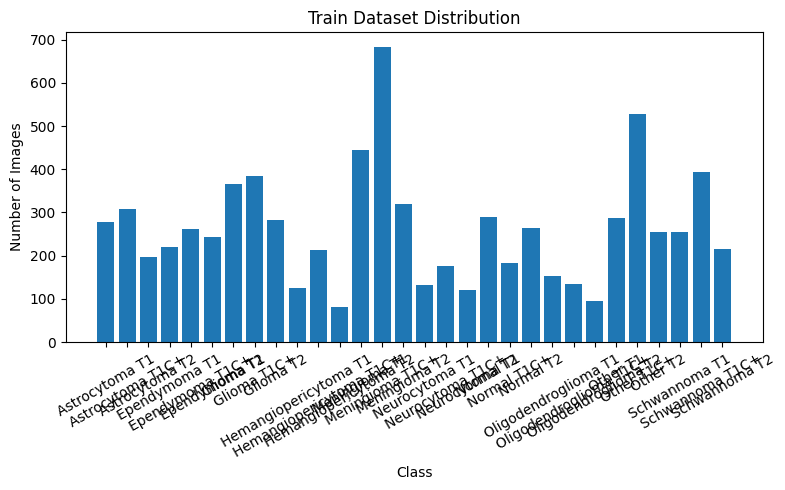

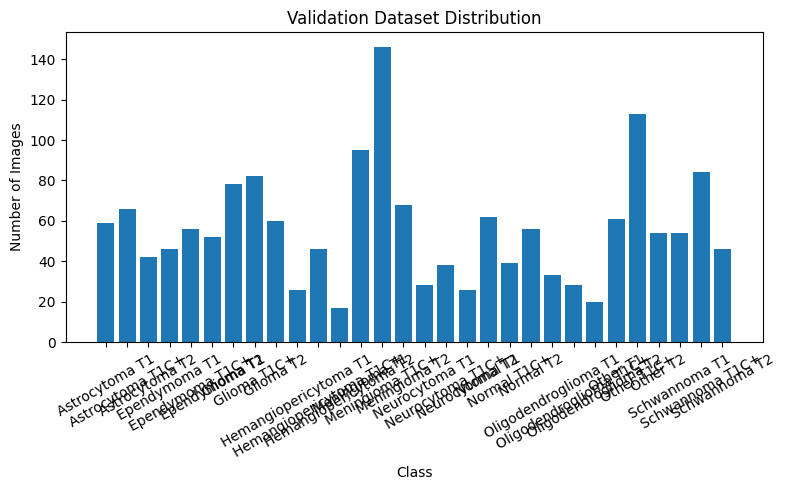

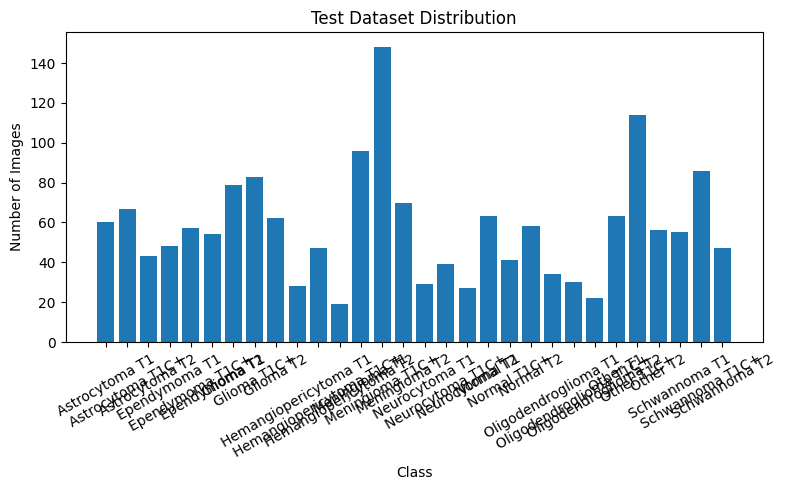

In [7]:
def plot_class_distribution(df, title, save_path):
    plt.figure(figsize=(8, 5))
    plt.bar(df["class_name"], df["image_count"])
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


plot_class_distribution(
    train_count_df,
    "Train Dataset Distribution",
    FIGURE_DIR / "train_distribution.png"
)

plot_class_distribution(
    val_count_df,
    "Validation Dataset Distribution",
    FIGURE_DIR / "val_distribution.png"
)

plot_class_distribution(
    test_count_df,
    "Test Dataset Distribution",
    FIGURE_DIR / "test_distribution.png"
)

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

train_data = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_data = val_test_datagen.flow_from_directory(
    directory=VAL_DIR,
    target_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    directory=TEST_DIR,
    target_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
CLASS_NAMES = list(train_data.class_indices.keys())

print("Number of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)
print("Class indices:", train_data.class_indices)

Found 7894 images belonging to 30 classes.
Found 1681 images belonging to 30 classes.
Found 1725 images belonging to 30 classes.
Number of classes: 30
Class names: ['Astrocytoma T1', 'Astrocytoma T1C+', 'Astrocytoma T2', 'Ependymoma T1', 'Ependymoma T1C+', 'Ependymoma T2', 'Glioma T1', 'Glioma T1C+', 'Glioma T2', 'Hemangiopericytoma T1', 'Hemangiopericytoma T1C+', 'Hemangiopericytoma T2', 'Meningioma T1', 'Meningioma T1C+', 'Meningioma T2', 'Neurocytoma T1', 'Neurocytoma T1C+', 'Neurocytoma T2', 'Normal T1', 'Normal T1C+', 'Normal T2', 'Oligodendroglioma T1', 'Oligodendroglioma T1C+', 'Oligodendroglioma T2', 'Other T1', 'Other T1C+', 'Other T2', 'Schwannoma T1', 'Schwannoma T1C+', 'Schwannoma T2']
Class indices: {'Astrocytoma T1': 0, 'Astrocytoma T1C+': 1, 'Astrocytoma T2': 2, 'Ependymoma T1': 3, 'Ependymoma T1C+': 4, 'Ependymoma T2': 5, 'Glioma T1': 6, 'Glioma T1C+': 7, 'Glioma T2': 8, 'Hemangiopericytoma T1': 9, 'Hemangiopericytoma T1C+': 10, 'Hemangiopericytoma T2': 11, 'Meningioma 

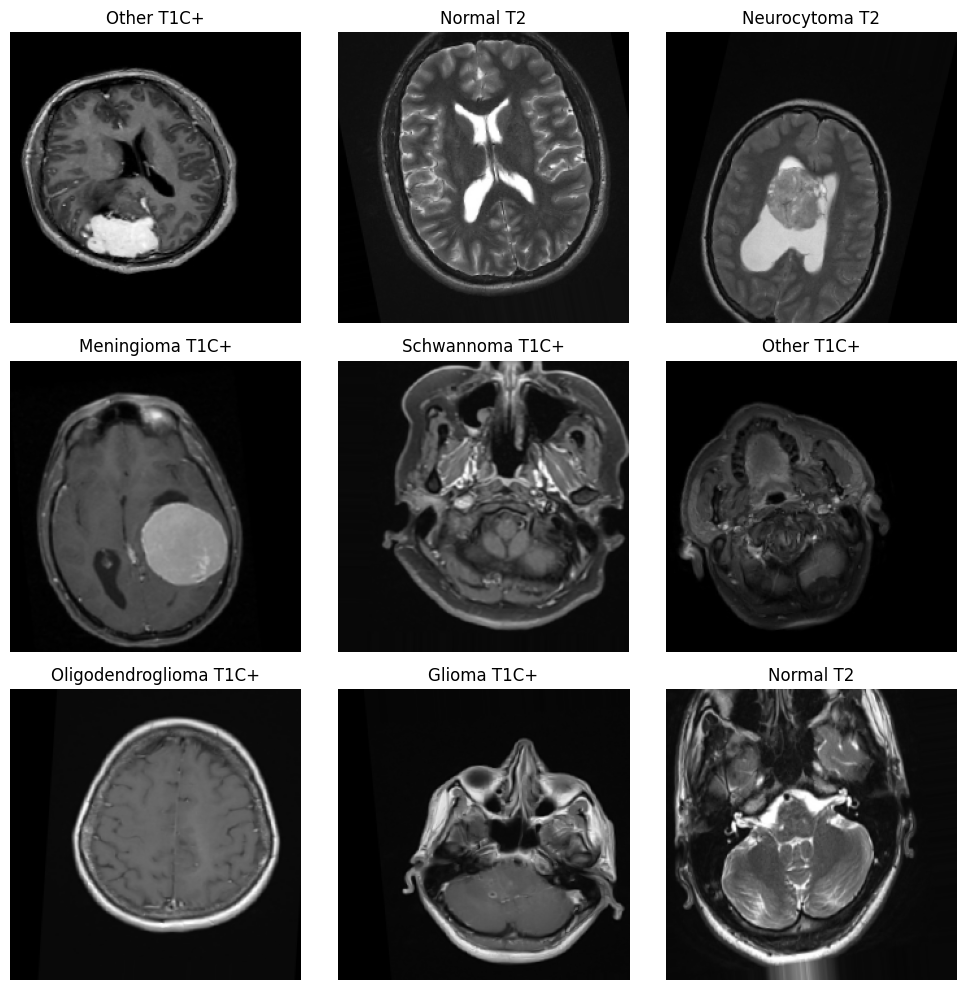

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 30)
Pixel min: 0.0
Pixel max: 1.0


In [9]:
images, labels = next(train_data)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    class_index = np.argmax(labels[i])
    class_name = CLASS_NAMES[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "preprocessed_sample_images.png")
plt.show()

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel min:", images.min())
print("Pixel max:", images.max())

# **Build baseline CNN model**

In [10]:
# def build_baseline_cnn(input_shape, num_classes):
#     model = models.Sequential(name="Baseline_CNN")

#     model.add(layers.Input(shape=input_shape))

#     model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
#     model.add(layers.MaxPooling2D(pool_size=(2, 2)))

#     model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
#     model.add(layers.MaxPooling2D(pool_size=(2, 2)))

#     model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
#     model.add(layers.MaxPooling2D(pool_size=(2, 2)))

#     model.add(layers.Conv2D(256, (3, 3), activation="relu", padding="same"))
#     model.add(layers.MaxPooling2D(pool_size=(2, 2)))

#     model.add(layers.Flatten())

#     model.add(layers.Dense(256, activation="relu"))
#     model.add(layers.Dropout(0.5))

#     model.add(layers.Dense(128, activation="relu"))
#     model.add(layers.Dropout(0.3))

#     model.add(layers.Dense(num_classes, activation="softmax"))

#     return model


# input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)

# model = build_baseline_cnn(
#     input_shape=input_shape,
#     num_classes=NUM_CLASSES
# )

# model.summary()

In [12]:


def build_baseline_cnn(input_shape, num_classes):
    model = models.Sequential(name="Lightweight_CNN")

    model.add(layers.Input(shape=input_shape))

    # Block 1
    model.add(layers.Conv2D(16, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 4
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))

    # Thay Flatten bằng GAP
    model.add(layers.GlobalAveragePooling2D())

    # Classifier nhỏ hơn
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(num_classes, activation="softmax"))

    return model


input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)

model = build_baseline_cnn(
    input_shape=input_shape,
    num_classes=NUM_CLASSES
)

model.summary()

Model: "Lightweight_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,646 (420.49 KB)

 Trainable params: 107,646 (420.49 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
# define callbacks
best_model_path = MODEL_DIR / "baseline_cnn_best.keras"
final_model_path = MODEL_DIR / "baseline_cnn_final.keras"
train_log_path = LOG_DIR / "baseline_training_log.csv"

callbacks = [
    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    CSVLogger(
        filename=train_log_path,
        append=False
    )
]

In [15]:
# train model baseline
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.0688 - loss: 3.3509
Epoch 1: val_accuracy improved from None to 0.08685, saving model to models/baseline_cnn_best.keras

Epoch 1: finished saving model to models/baseline_cnn_best.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.0739 - loss: 3.3295 - val_accuracy: 0.0869 - val_loss: 3.2767 - learning_rate: 0.0010
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.0772 - loss: 3.2931
Epoch 2: val_accuracy did not improve from 0.08685
247/247 ━━━━━━━━━━━━━━━━━━━━ 139s 560ms/step - accuracy: 0.0809 - loss: 3.2673 - val_accuracy: 0.0815 - val_loss: 3.2260 - learning_rate: 0.0010
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.0863 - loss: 3.1904
Epoch 3: val_accuracy improved from 0.08685 to 0.10708, saving model to models/baseline_cnn_best.keras

Epoch 3: finished saving model to models/baseline_cnn_best.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 144s 584ms/step - accuracy: 0.0923

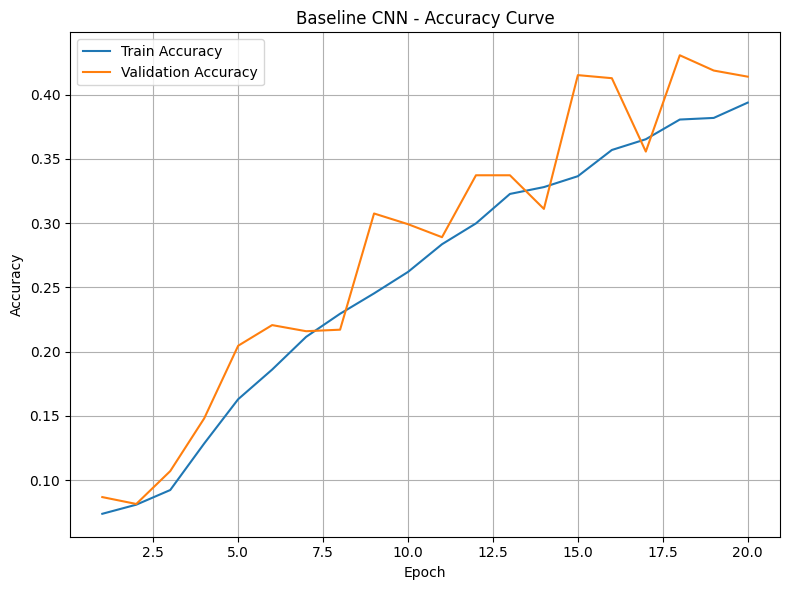

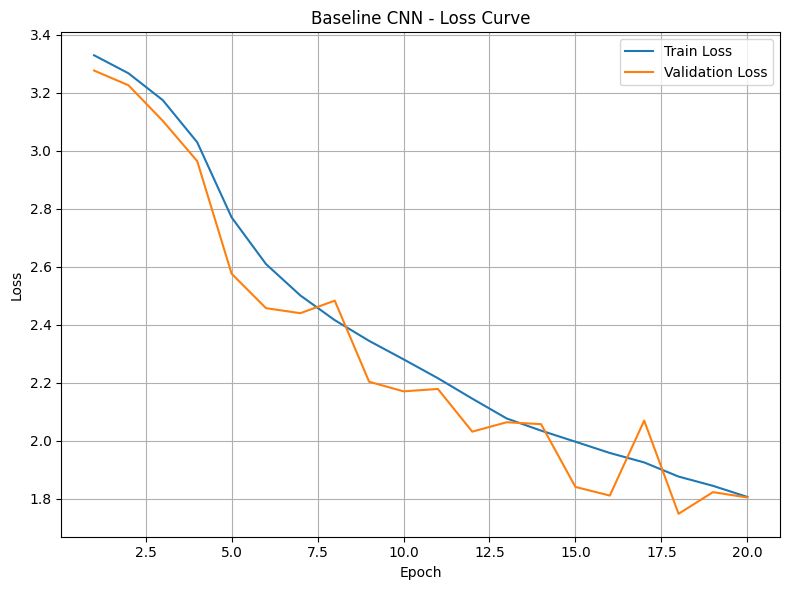

In [16]:
def plot_training_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title("Baseline CNN - Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "baseline_accuracy_curve.png")
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title("Baseline CNN - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "baseline_loss_curve.png")
    plt.show()


plot_training_history(history)

In [17]:
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 1369s 26s/step - accuracy: 0.4249 - loss: 1.7761
Test Loss     : 1.7761
Test Accuracy : 0.4249


In [18]:
test_data.reset()

y_pred_prob = model.predict(test_data, verbose=1)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_data.classes

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step
y_true shape: (1725,)
y_pred shape: (1725,)


In [19]:
accuracy = accuracy_score(y_true, y_pred)

precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

metrics_summary = {
    "model_name": "Baseline CNN",
    "image_size": str(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "epochs": len(history.history["loss"]),
    "test_loss": float(test_loss),
    "test_accuracy": float(accuracy),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "precision_weighted": float(precision_weighted),
    "recall_weighted": float(recall_weighted),
    "f1_weighted": float(f1_weighted)
}

metrics_df = pd.DataFrame([metrics_summary])

display(metrics_df)

metrics_df.to_csv(
    REPORT_DIR / "baseline_metrics_summary.csv",
    index=False
)

,model_name,image_size,batch_size,epochs,test_loss,test_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Baseline CNN,"(224, 224)",32,20,1.776129,0.424928,0.464788,0.385897,0.388804,0.455693,0.424928,0.408348


In [20]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(report)

report_path = REPORT_DIR / "baseline_classification_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print(f"Classification report saved to: {report_path}")

                         precision    recall  f1-score   support

         Astrocytoma T1     0.2917    0.2333    0.2593        60
       Astrocytoma T1C+     0.4000    0.0896    0.1463        67
         Astrocytoma T2     0.4545    0.1163    0.1852        43
          Ependymoma T1     0.5333    0.5000    0.5161        48
        Ependymoma T1C+     0.5789    0.3860    0.4632        57
          Ependymoma T2     0.5128    0.3704    0.4301        54
              Glioma T1     0.3789    0.7722    0.5083        79
            Glioma T1C+     0.3290    0.6145    0.4286        83
              Glioma T2     0.2174    0.6452    0.3252        62
  Hemangiopericytoma T1     0.3846    0.3571    0.3704        28
Hemangiopericytoma T1C+     0.8387    0.5532    0.6667        47
  Hemangiopericytoma T2     1.0000    0.2632    0.4167        19
          Meningioma T1     0.4194    0.5417    0.4727        96
        Meningioma T1C+     0.4439    0.5608    0.4955       148
          Meningioma T2 

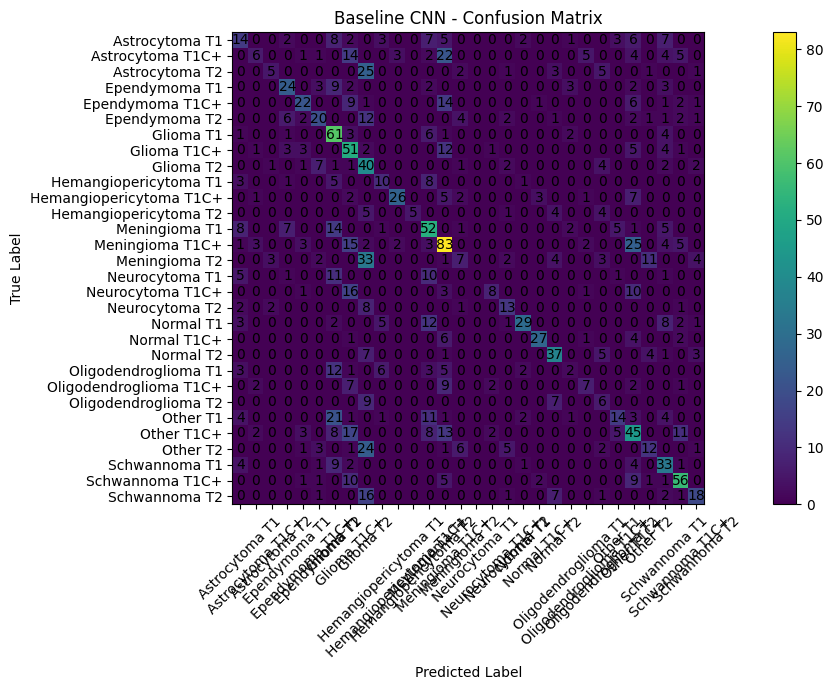

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14 ,7))
plt.imshow(cm, interpolation="nearest")
plt.title("Baseline CNN - Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            horizontalalignment="center",
            verticalalignment="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_confusion_matrix.png")
plt.show()

In [24]:
model.save(final_model_path)

print(f"Best model saved to : {best_model_path}")
print(f"Final model saved to: {final_model_path}")

Best model saved to : models/baseline_cnn_best.keras
Final model saved to: models/baseline_cnn_final.keras


In [25]:
class_indices_path = REPORT_DIR / "class_indices.json"

with open(class_indices_path, "w", encoding="utf-8") as f:
    json.dump(train_data.class_indices, f, ensure_ascii=False, indent=4)

print(f"Class indices saved to: {class_indices_path}")
print(train_data.class_indices)

Class indices saved to: reports/class_indices.json
{'Astrocytoma T1': 0, 'Astrocytoma T1C+': 1, 'Astrocytoma T2': 2, 'Ependymoma T1': 3, 'Ependymoma T1C+': 4, 'Ependymoma T2': 5, 'Glioma T1': 6, 'Glioma T1C+': 7, 'Glioma T2': 8, 'Hemangiopericytoma T1': 9, 'Hemangiopericytoma T1C+': 10, 'Hemangiopericytoma T2': 11, 'Meningioma T1': 12, 'Meningioma T1C+': 13, 'Meningioma T2': 14, 'Neurocytoma T1': 15, 'Neurocytoma T1C+': 16, 'Neurocytoma T2': 17, 'Normal T1': 18, 'Normal T1C+': 19, 'Normal T2': 20, 'Oligodendroglioma T1': 21, 'Oligodendroglioma T1C+': 22, 'Oligodendroglioma T2': 23, 'Other T1': 24, 'Other T1C+': 25, 'Other T2': 26, 'Schwannoma T1': 27, 'Schwannoma T1C+': 28, 'Schwannoma T2': 29}


In [26]:
best_model = tf.keras.models.load_model(best_model_path)

best_test_loss, best_test_accuracy = best_model.evaluate(test_data, verbose=1)

print(f"Best Model Test Loss     : {best_test_loss:.4f}")
print(f"Best Model Test Accuracy : {best_test_accuracy:.4f}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 182ms/step - accuracy: 0.4249 - loss: 1.7761
Best Model Test Loss     : 1.7761
Best Model Test Accuracy : 0.4249


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step


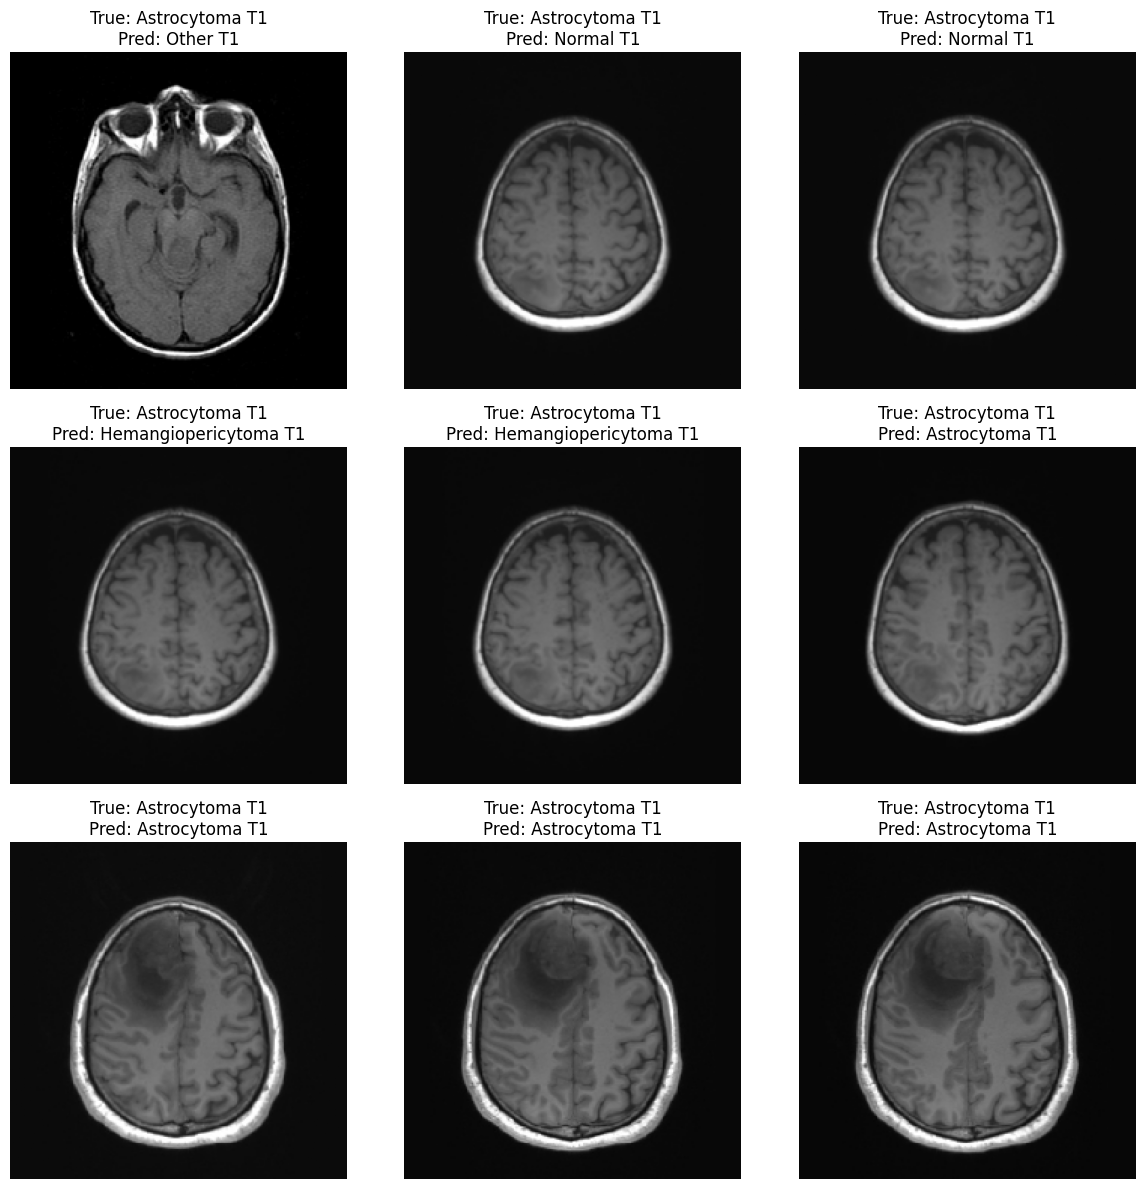

In [27]:
test_data.reset()

sample_images, sample_labels = next(test_data)

sample_pred_prob = best_model.predict(sample_images)
sample_pred = np.argmax(sample_pred_prob, axis=1)
sample_true = np.argmax(sample_labels, axis=1)

plt.figure(figsize=(12, 12))

for i in range(min(9, len(sample_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])

    true_label = CLASS_NAMES[sample_true[i]]
    pred_label = CLASS_NAMES[sample_pred[i]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_prediction_samples.png")
plt.show()